## Data Analysis using Python
## Week 3, Day 1: Data Cleaning (continue)

### 1. Outliers

#### 1.1 Identifying Outliers
We’ll use the `age` column from the `patients.xlsx` file as an example.

|Method|When to Use|
|-|-|
|Z-Score|For normally distributed data.|
|IQR Method|Simple and effective for most datasets.|


##### 1.1.1 Z-Score Method
The Z-Score indicates how many standard deviations a data point is from the mean. Outliers typically have a Z-Score beyond a threshold (commonly ±3).

**Formula:** $Z = \frac{x - \mu}{\sigma}$


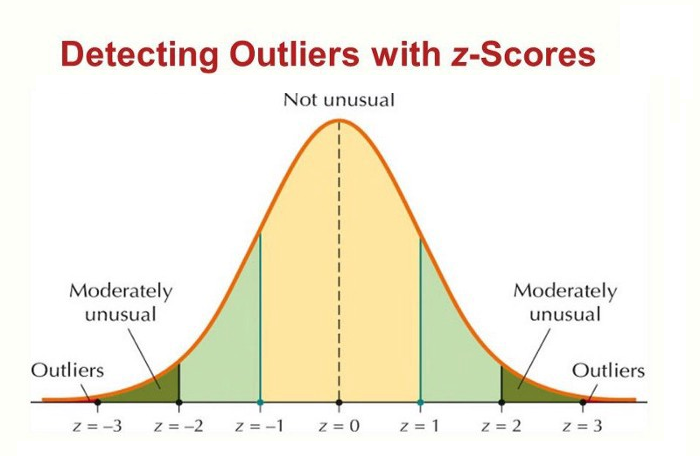

In [1]:
# read the files patients.xlsx and appointments.xlsx


In [2]:
# Calculate age mean

# Calculate age STD

# Calculate ages Z-Scores


In [3]:
# Identify outliers with Z-Score > 2 or < -2


##### 1.1.2 IQR Method
The **Interquartile Range** (IQR) Method is a statistical technique used to identify outliers in a dataset. It measures the range within which the central **50%** of the data lies and uses this range to define acceptable bounds for data points. Outliers are any values that fall significantly outside this range.

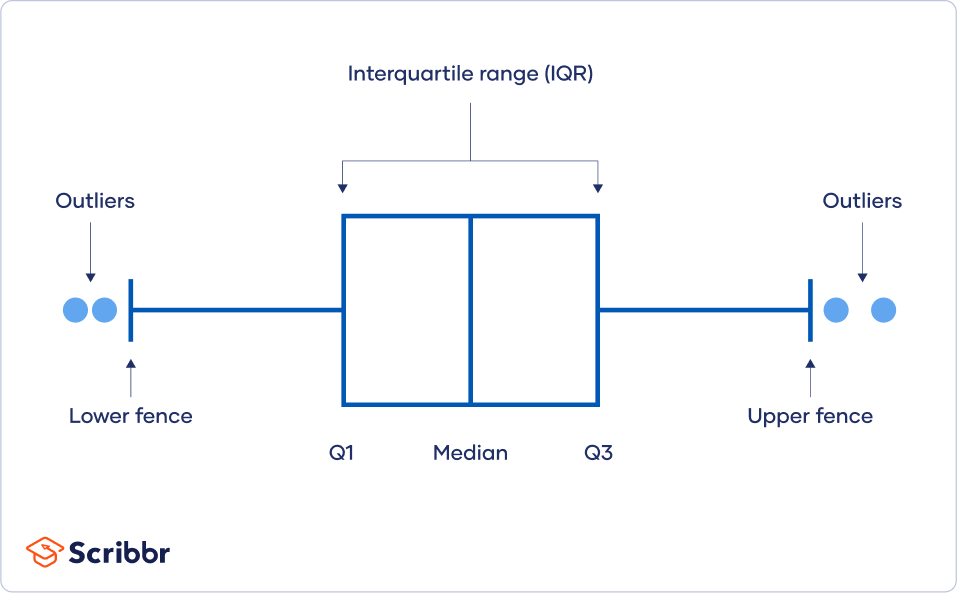

In [4]:
# Calculate Q1, Q3, and IQR witrh method quantile



In [5]:
# Define lower and upper at 0.75 of the IQR bounds for outliers


In [6]:
# Identify outliers



#### 1.2 Handling Outliers
##### 1.2.1 Removing Outliers
**When to Use:** If the outliers are errors or not relevant to your analysis.



In [7]:
# Remove rows containing outliers.


##### 1.2.2 Replacing Outliers
**When to Use:** When outliers are legitimate but extreme, and you want to reduce their impact.



In [8]:
# Copy the patients data frame


In [9]:
# Replace outliers with the median age

# Calculate age median

# set outliers ages to the median


In [10]:
# Check if it's changed


##### 1.2.3 Capping Outliers
**When to Use:** When you want to preserve all data while limiting extreme values.



In [11]:
# print the lower and upper bounds calculated earlier


In [12]:
# Cap outliers with the apply method


In [13]:
# Check if it's changed



### 2. Converting Btw Numerical & Categorical

#### 2.1 Converting Numerical Data to Categorical

**Scenario:**
You want to group the numerical `age` column from the `patients.xlsx` dataset into meaningful age categories, such as:

* **Child:** 0-17 years
* **Young Adult:** 18-35 years
* **Middle-Aged:** 36-55 years
* **Senior:** 56+ years

##### 2.1.1 Using Conditions (Custom Logic)
You can use conditional logic with `numpy` or `pandas` to create categories dynamically.

In [14]:
# Categorize 'age' using custom conditions


##### 2.1.2 Using `pd.cut()` for Binning
`pd.cut()` Parameters:

* **bins:** Defines the intervals for categorization.
* **labels:** Names for the resulting categories.
* **right:** If `True`, the intervals include the rightmost edge (e.g., 35 is part of Young Adult).

In [15]:
# Define age categories and labels



In [16]:
# Convert 'age' into categorical data


In [17]:
# Count the values in each group


##### 2.1.3 Using `pd.qcut()` for Quantile-Based Binning

This method creates bins of approximately equal size based on the distribution of the data.



In [18]:
# Divide 'copay_amount' into 4 quartiles


In [19]:
# Count the values in each group


##### Comparison of Methods
|Approach|When to Use|
|-|-|
|Custom Conditions|When you need full control or have complex logic.|
|`pd.cut()`|When you have predefined bins and labels.|
|`pd.qcut()`|When you want equal-sized bins based on data distribution.|

#### 2.2 Converting Categorical Data to Numerical

When converting categorical data to numerical values, there are three common approaches:




##### 2.2.1 Label Encoding

**Description:**

* Converts each category into a unique integer.
* Suitable for ordinal data (e.g., education level: "High School" → 1, "Bachelor" → 2).

In [20]:
# Use pandas.factorize() to encode the blood_type column


**Explanation:**

Each unique blood type is assigned a unique integer.

The method automatically handles missing values as -1.

##### 2.2.2 One-Hot Encoding
**Description:**

* Converts categories into binary columns (1 or 0).
* Suitable for nominal data (e.g., gender, country).

In [21]:
# Apply one-hot encoding to the 'insurance_provider' column


##### 2.2.3 Target Encoding
**Description:**

* Replaces categories with the mean of the target variable (e.g., average outcome per category).
* Useful for high-cardinality data.

Note: will explain next session

### **Challenge 1: Analyzing Patient Ages and Appointment Costs**

🏥 **Scenario**: You’ve been tasked to clean and analyze data to identify trends in patient demographics and copay amounts. Your goal is to:

1.  Identify outliers in the `age` column of the **patients.xlsx** dataset.
2.  Convert `age` into categorical age groups (e.g., Child, Young Adult, etc.).
3.  Encode the `insurance_provider` column from **appointments.xlsx** into numerical values.

#### **Instructions**:

1.  **Dealing with Outliers**:
    
    -   Use the IQR method to identify outliers in the `age` column.
    -   Remove rows where the `age` is an outlier.
2.  **Numerical to Categorical**:
    
    -   Create the following age groups in the `patients.xlsx` dataset:
        -   **Child**: 0−17
        -   **Young Adult**: 18−35
        -   **Middle-Aged**: 36−55
        -   **Senior**: 56+
3.  **Categorical to Numerical**:
    
    -   Encode the `insurance_provider` column in **appointments.xlsx** using:
        -   **Label Encoding**.
        -   **One-Hot Encoding** (compare the output of both methods).

### **Challenge 2: Segmentation and Encoding for Analysis**

🏥 **Scenario**: Your team is preparing data for a machine learning model and needs clean, segmented, and encoded data. You need to:

1.  Handle missing values and outliers in both datasets.
2.  Segment data for analysis by converting numerical values to meaningful categories.
3.  Encode categorical data for numerical use in models.

#### **Instructions**:

1.  **Handle Missing Values and Outliers**:
    
    -   In **patients.xlsx**, fill missing values in the `age` column with the median age.
    -   In **appointments.xlsx**, handle missing values in the `copay_amount` column by replacing them with the mean.
    -   Identify and cap outliers in both the `age` and `copay_amount` columns using the IQR method.
2.  **Numerical to Categorical**:
    
    -   Convert the `copay_amount` column in **appointments.xlsx** into tiers:
        -   **Low**: Copay<20
        -   **Medium**: 20≤Copay<50
        -   **High**: Copay≥50
3.  **Categorical to Numerical**:
    
    -   In **patients.xlsx**, encode the `blood_type` column using:
        -   A mapping dictionary.
    -   In **appointments.xlsx**, encode the `reason_for_visit` column using `pandas.factorize()`.